In [1]:
!pip install ftfy regex tqdm
!pip install torch==2.7.1 torchvision==0.22.1 cuda-bindings==12.9.*
!pip install --no-deps git+https://github.com/openai/CLIP.git
!pip install --no-deps retina-face

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158

In [2]:
from pathlib import Path
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math

from retinaface import RetinaFace
from skimage import transform as trans
import clip
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

2026-06-24 17:18:34.812529: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782321514.986777      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782321515.033749      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782321515.428928      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782321515.428960      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782321515.428962      23 computation_placer.cc:177] computation placer alr

In [3]:
torch.manual_seed(42)
np.random.seed(42)

DATA_DIR = Path("/kaggle/input/datasets/ahmedelbanby/faceforensicsplusplus-c23-deepfakebench-structure/videos/FaceForensics++")
ORIGINAL_DATA_DIR = DATA_DIR / "original_sequences" / "youtube" / "c23" / "videos"
OUT_DIR = Path("/kaggle/working/train")
DEEPFAKE_METHODS = ["Deepfakes", "Face2Face", "FaceShifter", "FaceSwap"]
N_DATA = 50
DTYPE = torch.float32
TOTAL_FRAMES = 32
IMG_DIMS = (224, 224)
SCALE = 1.3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32

OUT_DIR.mkdir(parents=True, exist_ok=True)

## Data preprocessing

In [4]:
def get_pairs(datapath: Path):
    """
    Pairs each fake video from the path with its real counterpart.
    """
    return [(x, ORIGINAL_DATA_DIR / (x.stem[:x.stem.find("_")] + ".mp4")) for x in datapath.iterdir()]


videos = {}
data_part = DATA_DIR / "manipulated_sequences" / DEEPFAKE_METHODS[0] / "c23" / "videos"
videos[DEEPFAKE_METHODS[0]] = get_pairs(data_part)

n = len(videos[DEEPFAKE_METHODS[0]])
print(f"There are {n} deepfake videos in the training dataset.")

There are 1000 deepfake videos in the training dataset.


In [5]:
# choose N_DATA random indices without replacement from 1 method.
# We then get all the others methods and the real video for those chosen videos.
chosen_indices = np.random.permutation(n)[:N_DATA]
chosen_pairs = [videos[DEEPFAKE_METHODS[0]][i] for i in chosen_indices]

videos = []
# recuperate the paths of the other fake methods from the first one.
for method in DEEPFAKE_METHODS:
    videos.extend([Path(str(x).replace(DEEPFAKE_METHODS[0], method)) for x, y in chosen_pairs])

# Add in the real video paths.
videos.extend([y for _, y in chosen_pairs])

In [6]:
def sample_video(path, n_frames = TOTAL_FRAMES):
    cap = cv2.VideoCapture(path)
    skip_rate = round(cap.get(cv2.CAP_PROP_FRAME_COUNT)) // n_frames
    frames = []
    i = 0

    while i<(n_frames*skip_rate):
        ret, frame = cap.read()
        assert ret
    
        if i%skip_rate == 0:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
    
        i += 1
    
    cap.release()
    assert len(frames) == n_frames, f"{path} has {len(frames)} frames."

    return np.stack(frames)

In [7]:
def img_align_crop(img, landmark=None, outsize=None, scale=1.3):
    """ 
    align and crop the face according to the given bbox and landmarks
    landmark: 5 key points
    """

    M = None
    target_size = [112, 112]
    dst = np.array([
        [30.2946, 51.6963],
        [65.5318, 51.5014],
        [48.0252, 71.7366],
        [33.5493, 92.3655],
        [62.7299, 92.2041]], dtype=np.float32)

    if target_size[1] == 112:
        dst[:, 0] += 8.0

    dst[:, 0] = dst[:, 0] * outsize[0] / target_size[0]
    dst[:, 1] = dst[:, 1] * outsize[1] / target_size[1]

    target_size = outsize

    margin_rate = scale - 1
    x_margin = target_size[0] * margin_rate / 2.
    y_margin = target_size[1] * margin_rate / 2.

    # move
    dst[:, 0] += x_margin
    dst[:, 1] += y_margin

    # resize
    dst[:, 0] *= target_size[0] / (target_size[0] + 2 * x_margin)
    dst[:, 1] *= target_size[1] / (target_size[1] + 2 * y_margin)

    src = landmark.astype(np.float32)

    # use skimage tranformation
    tform = trans.SimilarityTransform()
    tform.estimate(src, dst)
    M = tform.params[0:2, :]

    # M: use opencv
    # M = cv2.getAffineTransform(src[[0,1,2],:],dst[[0,1,2],:])

    img = cv2.warpAffine(img, M, (target_size[1], target_size[0]))

    if outsize is not None:
        img = cv2.resize(img, (outsize[1], outsize[0]))

    return img

In [8]:
def preprocess_video(video: Path | np.ndarray, n_frames = TOTAL_FRAMES, 
                        outsize = IMG_DIMS, scale = SCALE):
    if isinstance(video, Path) or isinstance(video, str):
        video = sample_video(video, n_frames)
    
    for frame in video:
        resp = RetinaFace.detect_faces(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
        assert resp is not None
            
        # We take the detected face with the highest confidence/score
        landmark = np.array(list(resp["face_1"]["landmarks"].values()))
        face = img_align_crop(frame, landmark, outsize=outsize, scale=scale)
        yield face

In [9]:
frames = []

for video, method in zip(videos, sum([[method] * N_DATA for method in (DEEPFAKE_METHODS + ["real"])], start = [])):
    for i, frame in enumerate(preprocess_video(video)):
        out_path = OUT_DIR / f"{video.stem}_{method}_{i}.bmp"
        frame = np.asarray(frame, np.uint8)
        assert cv2.imwrite(out_path, frame)
        frames.append(out_path)

y_train = torch.cat([torch.ones(TOTAL_FRAMES * N_DATA * 4), torch.zeros(TOTAL_FRAMES * N_DATA)], axis = 0)

I0000 00:00:1782321535.669568      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


26-06-24 17:18:58 - Directory /root/.deepface created
26-06-24 17:18:58 - Directory /root/.deepface/weights created
26-06-24 17:18:58 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5
100%|██████████| 119M/119M [00:00<00:00, 374MB/s]
I0000 00:00:1782321541.218636     138 cuda_dnn.cc:529] Loaded cuDNN version 90501


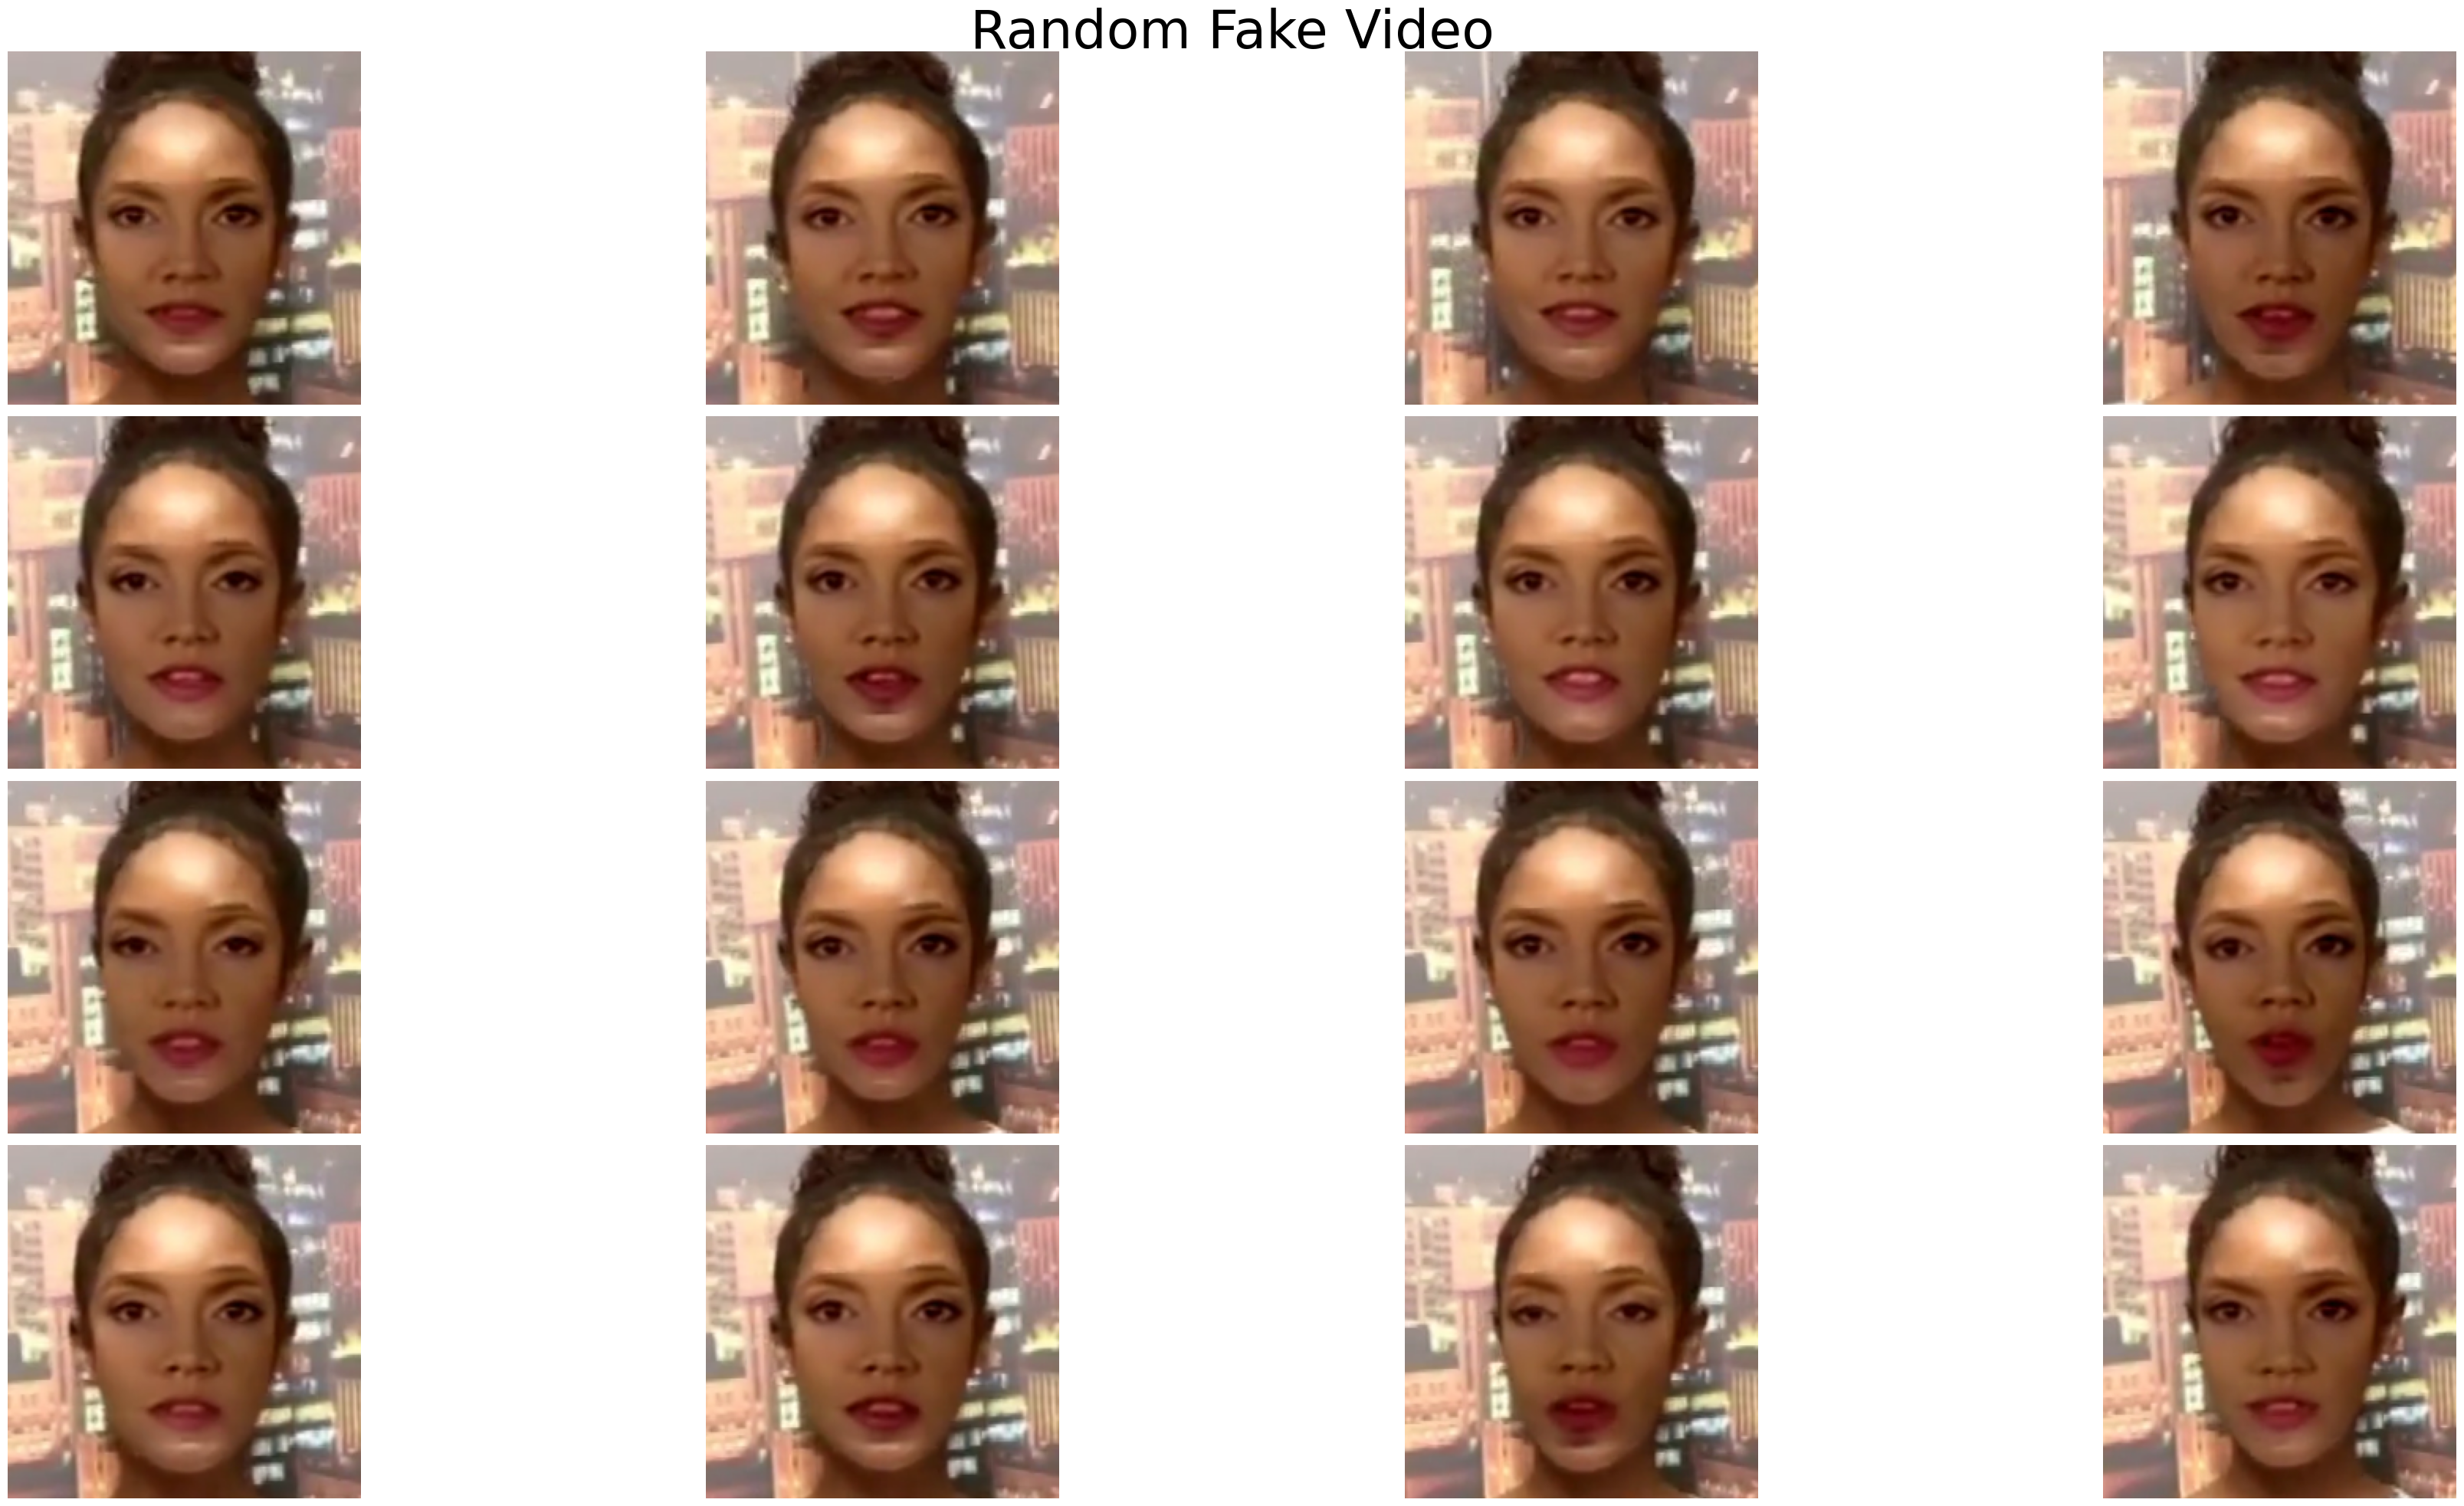

In [10]:
# Random fake example
idx = 0
example_path = videos[idx]

# its corresponding real video.
real_example = videos[4*N_DATA + (idx%N_DATA)]

fig, axs = plt.subplots(4, 4, figsize=(40, 20))
axs = axs.flatten()

for i, (frame, ax) in enumerate(zip(preprocess_video(example_path, TOTAL_FRAMES), axs)):
    ax.imshow(frame)
    ax.axis('off')

fig.suptitle("Random Fake Video", fontsize=50)
plt.tight_layout()
plt.show()

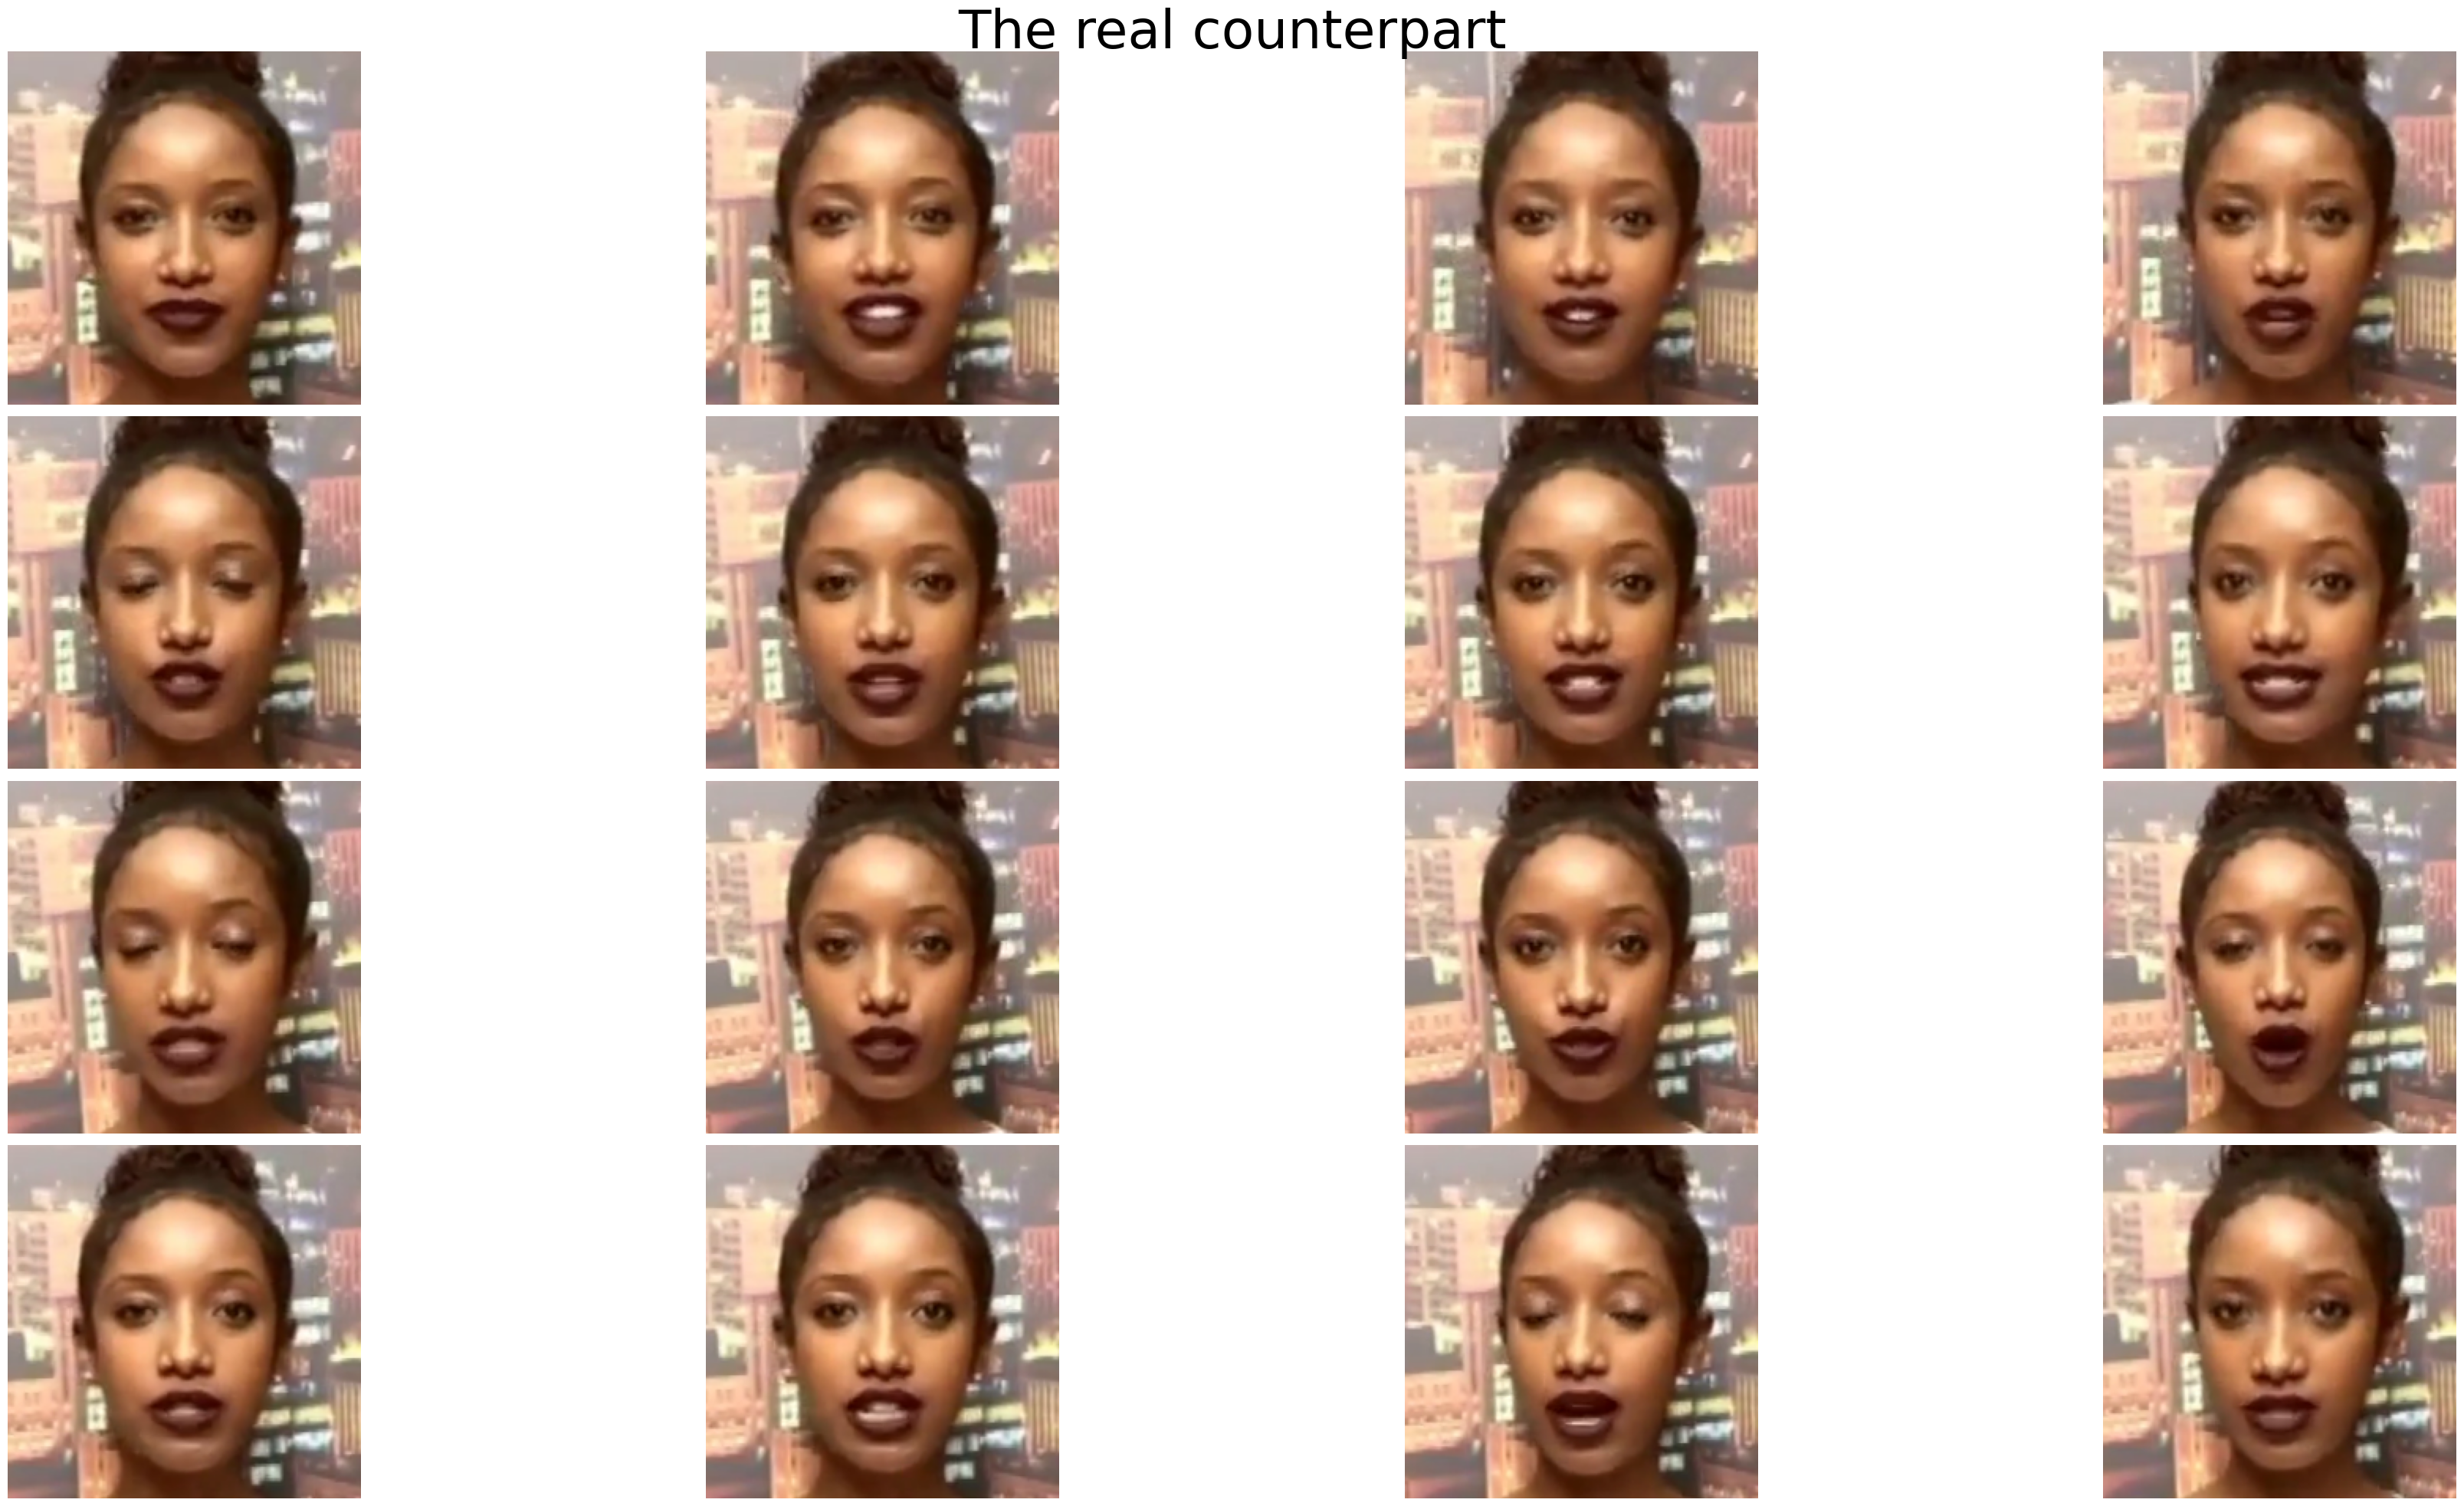

In [11]:
fig, axs = plt.subplots(4, 4, figsize=(40, 20))
axs = axs.flatten()

for i, (frame, ax) in enumerate(zip(preprocess_video(real_example, TOTAL_FRAMES), axs)):
    ax.imshow(frame)
    ax.axis('off')

fig.suptitle("The real counterpart", fontsize=50)
plt.tight_layout()
plt.show()

## Torch Dataset

In [12]:
class ImageDataset(Dataset):
    def __init__(self, imgs, labels, channels_first = True, transform = None):
        super().__init__()
        self.imgs = imgs
        self.labels = labels
        self.transform = None
        self.channels_first = channels_first

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = cv2.imread(self.imgs[idx]) / 255.0

        if self.transform:
            self.transform(img)
        if self.channels_first:
            img = np.transpose(img, (2, 0, 1))
    
        return torch.tensor(img, dtype = torch.float16), self.labels[idx]

clip_normalize = transforms.Normalize(
    (0.48145466, 0.4578275, 0.40821073),
    (0.26862954, 0.26130258, 0.27577711),)

data = ImageDataset(frames, y_train, transform = clip_normalize)

In [13]:
val_split = 0.3
num_workers = 1

n_val   = int(len(data) * val_split)
n_train = len(data) - n_val

generator = torch.Generator()
train_ds, val_ds = torch.utils.data.random_split(
    data, [n_train, n_val], generator=generator)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=num_workers)

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=num_workers)

## Model training

In [14]:
class L2Normalize(torch.nn.Module):
    def __init__(self, dim=1, eps=1e-12):
        super(L2Normalize, self).__init__()
        self.dim = dim
        self.eps = eps

    def forward(self, x):
        return torch.nn.functional.normalize(x, p=2, dim=1, eps=self.eps)

class CLIPBinaryClassifier(torch.nn.Module):
    """Wraps a CLIP visual encoder with a binary classification head."""
 
    def __init__(self, clip_model: torch.nn.Module):
        super().__init__()
        self.visual = clip_model.visual

        for name, param in self.visual.named_parameters():
            param.requires_grad = "ln" in name
 
        embed_dim = clip_model.visual.output_dim  # 768 for ViT-L/14
        self.l2 = L2Normalize()
        self.linear = torch.nn.Linear(embed_dim, 1, dtype = DTYPE)

 
    def forward(self, images: torch.Tensor) -> torch.Tensor:
        features = self.visual(images).float()
        l2 = self.l2(features)
        return self.linear(l2)


clip_model, _ = clip.load("ViT-L/14", device=DEVICE)
model = CLIPBinaryClassifier(clip_model).to(DEVICE)

100%|████████████████████████████████████████| 890M/890M [00:06<00:00, 140MiB/s]


In [15]:
class CLIPLoss(torch.nn.Module):
    def __init__(self, alpha = 0.0, beta = 0.0):
        super().__init__()
        self.bce = torch.nn.BCEWithLogitsLoss()
        self.align = torch.nn.Identity()
        self.uniform = torch.nn.Identity()
        self.alpha = alpha
        self.beta = beta

    def forward(self, outputs, labels):
        out, norm = outputs
        return self.bce(out, labels) + self.alpha * self.align(norm) + self.beta * self.uniform(norm)

In [16]:
def train(
    model,
    train_loader,
    val_loader,
    epochs: int = 10,
    batch_size: int = 32,
    lr: float = 1e-3,
    device: str | None = None,
    seed: int = 42,
) -> torch.nn.Module:
    """
    Train a CLIP ViT-L/14 binary classifier.
 
    Args:
        train_loader  : torch.utils.data.DataLoader; items are (image, label)
        epochs        : number of full passes through the training set.
        batch_size    : samples per gradient step.
        lr            : learning rate for Adam.
        val_split     : fraction of `data` held out for validation.
        freeze_backbone: freeze ViT trunk and only train the new head.
        device        : 'cuda', 'cpu', or None (auto-detect).
        seed          : random seed for reproducible train/val split.
 
    Returns:
        Trained model in eval mode.
    """
    print(f"Using device: {device}")
 
    # ── Model, loss, optimiser ───────────────────────────────────────────────
    criterion = torch.nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, 10, eta_min = 1e-5
    )
 
    best_val_loss = float("inf")
    best_state    = None
 
    # ── Epoch loop ───────────────────────────────────────────────────────────
    for epoch in range(1, epochs + 1):
 
        # — Training phase —
        model.train()
        train_loss = 0.0
        train_correct = 0
 
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.unsqueeze(1).to(device)   # (B,) → (B, 1)
 
            optimizer.zero_grad()
            outputs = model(images)                            # (B, 1) in [0, 1]
            loss    = criterion(outputs, labels)
    
            loss.backward()
            optimizer.step()

            
            train_loss    += loss.item() * images.size(0)
            preds          = (outputs >= 0).float()
            train_correct += (preds == labels).sum().item()
 
        train_loss /= n_train
        train_acc   = train_correct / n_train
        
 
        # — Validation phase —
        model.eval()
        val_loss = 0.0
        val_correct = 0
 
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)
 
                outputs     = model(images)
                loss        = criterion(outputs, labels)
                val_loss   += loss.item() * images.size(0)
                preds       = (outputs >= 0.).float()
                val_correct += (preds == labels).sum().item()
 
        val_loss /= n_val
        val_acc   = val_correct / n_val
 
        scheduler.step(val_loss)
 
        print(
            f"Epoch {epoch:>3}/{epochs} | "
            f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
            f"Val   loss: {val_loss:.4f}, acc: {val_acc:.4f}"
        )
 
        # Save the best checkpoint
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"  ✓ New best model saved (val_loss={best_val_loss:.4f})")
 
    # ── Restore best weights ─────────────────────────────────────────────────
    if best_state is not None:
        model.load_state_dict(best_state)
 
    return model.eval()

train(model, train_loader, val_loader, epochs = 10, lr = 3e-4, batch_size = BATCH_SIZE, device = DEVICE)
print("Training done.")

Using device: cuda
Epoch   1/10 | Train loss: 0.5956, acc: 0.7982 | Val   loss: 0.5199, acc: 0.8042
  ✓ New best model saved (val_loss=0.5199)
Epoch   2/10 | Train loss: 0.4928, acc: 0.7982 | Val   loss: 0.4633, acc: 0.8042
  ✓ New best model saved (val_loss=0.4633)
Epoch   3/10 | Train loss: 0.4438, acc: 0.7982 | Val   loss: 0.4112, acc: 0.8042
  ✓ New best model saved (val_loss=0.4112)
Epoch   4/10 | Train loss: 0.3426, acc: 0.8337 | Val   loss: 0.2670, acc: 0.9229
  ✓ New best model saved (val_loss=0.2670)
Epoch   5/10 | Train loss: 0.2214, acc: 0.9448 | Val   loss: 0.2055, acc: 0.9483
  ✓ New best model saved (val_loss=0.2055)
Epoch   6/10 | Train loss: 0.1748, acc: 0.9575 | Val   loss: 0.1556, acc: 0.9579
  ✓ New best model saved (val_loss=0.1556)
Epoch   7/10 | Train loss: 0.1180, acc: 0.9721 | Val   loss: 0.1200, acc: 0.9650
  ✓ New best model saved (val_loss=0.1200)
Epoch   8/10 | Train loss: 0.0905, acc: 0.9768 | Val   loss: 0.1015, acc: 0.9688
  ✓ New best model saved (val_lo

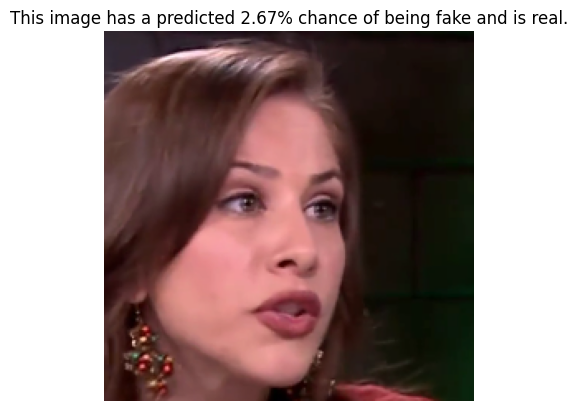

In [17]:
for imgs, labels in val_loader:
    for i in range(labels.shape[0]):
        img = imgs[i]
        label = labels[i].item()
        if not label:
            break
    if not label:
        break
    
plt.imshow(torch.permute(img, [1, 2, 0]).numpy().astype(np.float32))
out = torch.nn.Sigmoid()(model(img.unsqueeze(0).to(DEVICE)))
plt.title(f"This image has a predicted {out.item()*100:0.2f}% chance of being fake and is {"fake" if label else "real"}.")
plt.axis("off")
plt.show()